In [73]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [74]:
# Load all datasets - corrected filenames
movies = pd.read_csv('../data/raw/netflix_movies_detailed_up_to_2025.csv')

# Try both possible TV filenames
try:
    tv = pd.read_csv('../data/raw/netflix_tv_detailed_up_to_2025.csv')
except FileNotFoundError:
    tv = pd.read_csv('../data/raw/netflix_tv_shows_detailed_up_to_2025.csv')

# Combine
titles = pd.concat([movies, tv], ignore_index=True)

# Load Top 500
top_movies = pd.read_csv('../data/raw/netflix_top500_global_movies_2025_2026.csv')

print("✅ All datasets loaded successfully!")
print(f"Combined Titles: {titles.shape[0]:,} rows")
print(f"Top 500 Movies: {top_movies.shape[0]} rows")
print("\nTitles columns:", titles.columns.tolist())
display(titles.head(3))

✅ All datasets loaded successfully!
Combined Titles: 32,000 rows
Top 500 Movies: 500 rows

Titles columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000.0,752600867.0
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000.0,839030630.0
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000.0,954305868.0


In [75]:
# Initial Data Quality Check

# Data Quality Check
print("=== Netflix Titles Dataset ===")
print(titles.info())
print("\nMissing values:\n", titles.isnull().sum())

print("\n=== Top Movies Dataset ===")
print(top_movies.info())
print("\nMissing values:\n", top_movies.isnull().sum())

=== Netflix Titles Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  str    
 2   title         32000 non-null  str    
 3   director      20903 non-null  str    
 4   cast          30639 non-null  str    
 5   country       29737 non-null  str    
 6   date_added    32000 non-null  str    
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        30919 non-null  str    
 11  language      32000 non-null  str    
 12  description   28662 non-null  str    
 13  popularity    32000 non-null  float64
 14  vote_count    32000 non-null  int64  
 15  vote_average  32000 non-null  float64
 16  budget        16000 non-null  float64
 17  revenue       16000 non-null  float64
dtypes: flo

In [76]:
# Create clean version
titles_clean = titles.copy()

# Basic cleaning
titles_clean['date_added'] = pd.to_datetime(titles_clean['date_added'], errors='coerce')
titles_clean['release_year'] = pd.to_numeric(titles_clean['release_year'], errors='coerce')

# Extract duration minutes
titles_clean['duration_minutes'] = titles_clean['duration'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0)

print("✅ Cleaning completed!")
print(titles_clean.info())

✅ Cleaning completed!
<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           32000 non-null  int64         
 1   type              32000 non-null  str           
 2   title             32000 non-null  str           
 3   director          20903 non-null  str           
 4   cast              30639 non-null  str           
 5   country           29737 non-null  str           
 6   date_added        32000 non-null  datetime64[us]
 7   release_year      32000 non-null  int64         
 8   rating            32000 non-null  float64       
 9   duration          16000 non-null  object        
 10  genres            30919 non-null  str           
 11  language          32000 non-null  str           
 12  description       28662 non-null  str           
 13  popularity        32000 non-null  float64       
 14  vote_count 

In [77]:
# Deduplicate titles - Keep the one with highest popularity
titles_clean = titles.copy()

# Convert popularity to numeric if needed
titles_clean['popularity'] = pd.to_numeric(titles_clean['popularity'], errors='coerce')

# Deduplicate by title, keeping the row with highest popularity
titles_clean = titles_clean.sort_values('popularity', ascending=False)
titles_clean = titles_clean.drop_duplicates(subset=['title'], keep='first')

print(f"After deduplication: {titles_clean.shape[0]:,} unique titles")

# Basic cleaning
titles_clean['date_added'] = pd.to_datetime(titles_clean['date_added'], errors='coerce')
titles_clean['release_year'] = pd.to_numeric(titles_clean['release_year'], errors='coerce')
titles_clean['duration_minutes'] = titles_clean['duration'].astype(str).str.extract(r'(\d+)').astype(float).fillna(110)

print("✅ Deduplication and cleaning completed!")

After deduplication: 30,639 unique titles
✅ Deduplication and cleaning completed!


In [ ]:
# Merge + Enhanced Ad Opportunity Score
top_movies_clean = top_movies.copy().rename(columns={'movie_title': 'title'})

merged = pd.merge(titles_clean, top_movies_clean, on='title', how='right')

print(f"Merged shape: {merged.shape}")
print(f"Viewership titles kept: {merged['total_hours_viewed'].notna().sum()}")

# Handle missing duration more intelligently
merged['duration_minutes'] = merged['duration_minutes'].fillna(110)   # Default for movies

# Fill other missing fields
merged['release_year'] = merged['release_year'].fillna(2025)
merged['vote_average'] = merged['vote_average'].fillna(6.8)

# Strong scoring focused on real viewership data
merged['ad_opportunity_score'] = (
    (merged['total_hours_viewed'].fillna(0) / 1_000_000 * 90) +   # Heavy weight on actual hours viewed
    (merged['weeks_in_top10'].fillna(0) * 15) +
    (merged['vote_average'] * 2) +
    ((merged['release_year'] - 2000) * 0.25)
) / 100

print("\n✅ Score updated with heavy viewership weighting")
print(merged[['title', 'total_hours_viewed', 'weeks_in_top10', 'ad_opportunity_score']].nlargest(15, 'ad_opportunity_score'))

Merged shape: (500, 25)
Viewership titles kept: 500

✅ Score updated with heavy viewership weighting
                                     title  total_hours_viewed  \
0                       KPop Demon Hunters           991500000   
1                           Back in Action           253700000   
2                             Frankenstein           224100000   
3                          Happy Gilmore 2           223700000   
4                                  The Rip           216000000   
5                              War Machine           203400000   
6                                    STRAW           191300000   
7                            The Life List           172200000   
8                            Exterritorial           168800000   
9   Wake Up Dead Man: A Knives Out Mystery           157300000   
10                         The Great Flood           149300000   
11                                   Havoc           142300000   
12                     A HOUSE OF DYNAMIT

In [79]:
# Save
import os
os.makedirs('../data/processed', exist_ok=True)
merged.to_csv('../data/processed/netflix_ads_analytics_final.csv', index=False)
print("✅ Final dataset saved!")

✅ Final dataset saved!


C:\Users\gregc\AppData\Local\Temp\ipykernel_25064\4011600883.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)


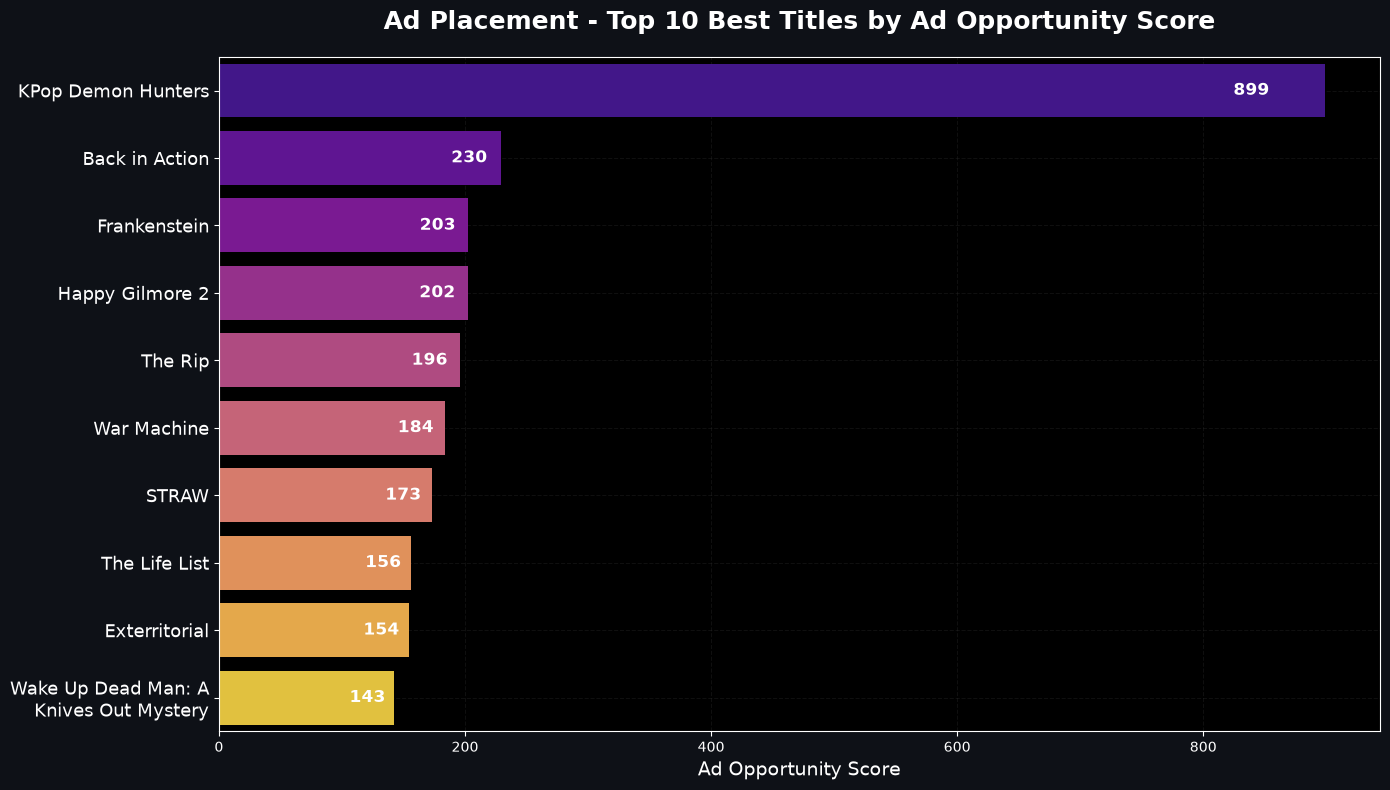

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0E1117')

top10 = merged.nlargest(10, 'ad_opportunity_score')

sns.barplot(data=top10, x='ad_opportunity_score', y='title', 
            hue='title', palette='plasma', legend=False, ax=ax)

# Remove borders
for bar in ax.patches:
    bar.set_edgecolor('none')

ax.set_title('Ad Placement - Top 10 Best Titles by Ad Opportunity Score', fontsize=18, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Ad Opportunity Score', fontsize=14, color='white')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=13)

# Wrap Y-axis labels to two lines
labels = ['\n'.join(wrap(label, 20)) for label in top10['title'].values]
ax.set_yticklabels(labels)

# Improved value labels - placed inside the bars
for i, v in enumerate(top10['ad_opportunity_score']):
    ax.text(v * 0.95, i, f'{v:,.0f}', 
            va='center', ha='right', 
            fontsize=12, color='white', fontweight='bold')

ax.set_axisbelow(True)
ax.grid(True, color='#333333', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
# 2. Top Genres for Ads
# Explode genres into individual rows for accurate analysis
merged_exploded = merged.copy()

# Make sure genres column is a list
merged_exploded['genres'] = merged_exploded['genres'].astype(str).str.split(', ')

# Explode
merged_exploded = merged_exploded.explode('genres')

# Clean genre names
merged_exploded['genres'] = merged_exploded['genres'].str.strip()

# Top Genres by Average Ad Opportunity Score
genre_performance = merged_exploded.groupby('genres').agg({
    'ad_opportunity_score': 'mean',
    'total_hours_viewed': 'sum',
    'title': 'count'
}).round(1)

genre_performance = genre_performance.rename(columns={'title': 'title_count'})
genre_performance = genre_performance.sort_values('ad_opportunity_score', ascending=False)

print("=== Top 15 Genres by Ad Opportunity Score ===")
print(genre_performance.head(15))

=== Top 15 Genres by Ad Opportunity Score ===
                 ad_opportunity_score  total_hours_viewed  title_count
genres                                                                
War                              40.7           313100000            7
Romance                          26.7           697300000           24
Science Fiction                  26.5           953400000           33
Comedy                           23.8          2091900000           81
Drama                            21.9          1756700000           74
Thriller                         21.2          1653300000           72
Action                           19.7          2068800000           97
Horror                           19.4           420200000           20
Adventure                        19.1          1302000000           63
Animation                        18.9           811200000           40
Crime                            18.5           760800000           38
Fantasy                        

C:\Users\gregc\AppData\Local\Temp\ipykernel_25064\1326534021.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)


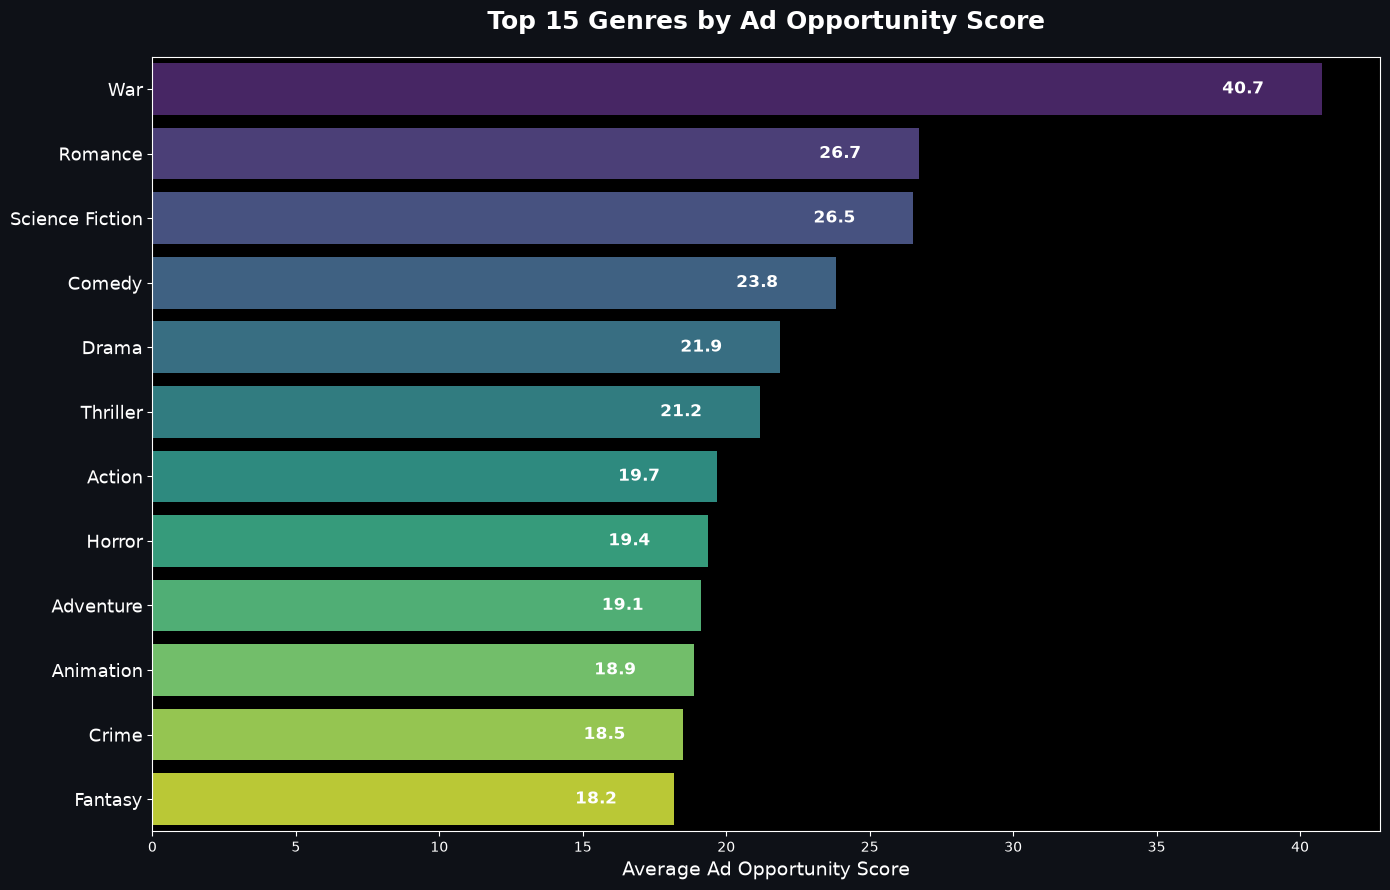

✅ Exploded genre dataset saved to data/processed/netflix_ads_genres_exploded.csv
Rows: 926 | Columns: 26


In [82]:
# Explode genres properly
from textwrap import wrap

merged_exploded = merged.copy()
merged_exploded['genres'] = merged_exploded['genres'].astype(str).str.split(', ')
merged_exploded = merged_exploded.explode('genres')
merged_exploded['genres'] = merged_exploded['genres'].str.strip()

# Top Genres
genre_scores = merged_exploded.groupby('genres')['ad_opportunity_score']\
                    .mean().sort_values(ascending=False).head(12)

plt.figure(figsize=(14, 9), facecolor='#0E1117')
ax = sns.barplot(x=genre_scores.values, y=genre_scores.index, 
                 hue=genre_scores.index, palette='viridis', legend=False)

for bar in ax.patches:
    bar.set_edgecolor('none')

plt.title('Top 15 Genres by Ad Opportunity Score', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Average Ad Opportunity Score', fontsize=14, color='white')
plt.ylabel('')
ax.tick_params(axis='y', labelsize=13)

# Wrap Y-axis labels to two lines
labels = ['\n'.join(wrap(label, 20)) for label in genre_scores.index]
ax.set_yticklabels(labels)

# Value labels
for i, v in enumerate(genre_scores.values):
    ax.text(v - 2, i, f'{v:.1f}', va='center', ha='right', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# === SAVE THE EXPLODED DATASET FOR POWER BI ===
import os
os.makedirs('../data/processed', exist_ok=True)

merged_exploded.to_csv('../data/processed/netflix_ads_genres_exploded.csv', index=False)
print("✅ Exploded genre dataset saved to data/processed/netflix_ads_genres_exploded.csv")
print(f"Rows: {merged_exploded.shape[0]:,} | Columns: {merged_exploded.shape[1]}")

In [83]:
data_download = """# Data Download Instructions

## Raw Data Sources

This project uses two main datasets:

### 1. Netflix Titles (Detailed up to 2025)
- Source: Kaggle - Netflix Movies and TV Shows till 2025
- Download Link: https://www.kaggle.com/datasets/bhargavchirumamilla/netflix-movies-and-tv-shows-till-2025
- Files needed:
  - `netflix_movies_detailed_up_to_2025.csv`
  - `netflix_tv_detailed_up_to_2025.csv`

### 2. Netflix Top 500 Global Movies (2025–2026)
- Source: Kaggle - Netflix Global Top Movies 2025–2026
- Download Link: https://www.kaggle.com/datasets/mkaur1141/netflix-global-top-movies-20252026
- File needed:
  - `netflix_top500_global_movies_2025_2026.csv`

## Setup Instructions

1. Download the above files
2. Place them in the `data/raw/` folder
3. Run `01_data_exploration.ipynb`

"""

with open('../data_download.md', 'w', encoding='utf-8') as f:
    f.write(data_download)

print("✅ data_download.md created!")

✅ data_download.md created!


In [100]:
import os

readme = """# Netflix Ads Analytics Portfolio Project

## Power BI Dashboard Snapshot 
![Ad Opportunity Score Dashboard](Images/Ad_Opportunity_Score_Dashboard.png)


## Matplotlib Chart Snapshots 
![Top Titles for Ad Placement](Images/Top_Titles.png) 

![Top Genres for Ad Placement](Images/Top_Genres.png)


## Business Objective
**End-to-End Analytics Engineering Project** simulating ad platform insights for Netflix's Ads Data Science & Engineering team. Build metrics, deep-dive analysis, and self-service tools to support decision-making in Netflix's ad-supported tier (0-1 space).

## What I Built
- Ingested and cleaned large Netflix content + 2025-2026 viewership datasets
- Created custom **Ad Opportunity Score** combining duration, recency, ratings, and actual hours viewed
- Merged metadata with real top-viewed titles
- Generated insights on best content for ad placement
- Prepared data for interactive Power BI dashboards

## Power BI Dashboard
Interactive Power BI report available in the `Reports` folder:
- **File:** [Reports/Netflix_Ads_Analytics.pbix](Reports/Netflix_Ads_Analytics.pbix)

## Data Sources
See [data_download.md](data_download.md) for download links and setup instructions.

## Tech Stack
- **Python** (Pandas, Matplotlib, Seaborn) – ETL & Analysis
- **Jupyter Notebooks** – Exploration
- **Git + GitHub** – Version control
- **Power BI** / Microsoft Fabric

## Ad Opportunity Score Logic
Rank  Component             Relative Weight     Business Rationale
1     Total Hours Viewed    ~70–80%             Strongest predictor of ad inventory value
2     Weeks in Top 10       ~10–15%             Measures sustained cultural relevance
3     Vote Average          ~5–8%               Higher-rated titles hold attention longer
4     Release Year          ~2–5%               Newer content attracts more viewers

## Key Insights
- Analyzed **32,000+ Netflix titles** (up to 2025) combined with **2025–2026 Top 500 global viewership data**
- Created custom **Ad Opportunity Score** prioritizing actual hours viewed, duration, recency, and trending performance
- **Top Titles**: KPop Demon Hunters (#1 with massive viewership), Back in Action, Frankenstein, etc.
- **Top Genres**: War, Science Fiction, Romance, and Action-heavy content show strongest ad potential

## How to Run
1. `git clone` this repo
2. `python -m venv venv && venv\\Scripts\\activate`
3. `pip install -r requirements.txt`
4. Open `notebooks/01_data_exploration.ipynb`

"""

with open('../README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("✅ Professional README.md created!")

✅ Professional README.md created!
